# momo-ml Demo Notebook

This notebook demonstrates basic usage of `momo-ml`, including:

- Running model monitoring (performance drift / data drift / prediction drift)
- Generating visual plots
- Exporting an HTML report

In [1]:
import pandas as pd
import numpy as np

from momo_ml.monitor import ModelMonitor
from momo_ml.utils.plotting import (
    plot_distribution,
    plot_feature_histograms,
    plot_deciles,
)
from momo_ml.report import ReportBuilder

import matplotlib.pyplot as plt

In [2]:
# Synthetic binary classification example

np.random.seed(42)

N = 1000

# Reference dataset (baseline)
ref_df = pd.DataFrame({
    "x1": np.random.normal(0, 1, N),
    "x2": np.random.normal(5, 2, N),
    "category": np.random.choice(["A", "B", "C"], size=N, p=[0.3, 0.5, 0.2]),
})

# Simulate true labels
ref_df["label"] = (ref_df["x1"] + np.random.normal(0, 1, N) > 0).astype(int)

# Simulate model predictions (probabilities)
ref_df["pred"] = ref_df["label"] * 0.7 + np.random.normal(0.2, 0.1, N)
ref_df["pred"] = ref_df["pred"].clip(0, 1)


# Current dataset with drift

cur_df = pd.DataFrame({
    "x1": np.random.normal(0.3, 1.2, N),    # shift in mean & variance
    "x2": np.random.normal(4.5, 2.5, N),    # shift
    "category": np.random.choice(["A", "B", "C"], size=N, p=[0.1, 0.7, 0.2]),
})

cur_df["label"] = (cur_df["x1"] + np.random.normal(0, 1, N) > 0.1).astype(int)
cur_df["pred"] = cur_df["label"] * 0.6 + np.random.normal(0.25, 0.15, N)
cur_df["pred"] = cur_df["pred"].clip(0, 1)

ref_df.head(), cur_df.head()

(         x1        x2 category  label      pred
 0  0.496714  7.798711        B      1  0.883566
 1 -0.138264  6.849267        A      0  0.221209
 2  0.647689  5.119261        B      1  0.800664
 3  1.523030  3.706126        A      1  0.798412
 4 -0.234153  6.396447        C      0  0.061146,
          x1         x2 category  label      pred
 0  0.883422  12.245749        B      1  0.473656
 1 -2.039246   3.854562        B      0  0.134685
 2 -2.160429   5.775311        C      0  0.181145
 3  1.187017   2.876588        B      0  0.337259
 4  0.908424   5.238081        B      1  0.882808)

In [4]:
monitor = ModelMonitor(
    ref_df=ref_df,
    cur_df=cur_df,
    label_col="label",
    pred_col="pred",
)

results = monitor.run_all()
results

{'performance_drift': {'task_type': 'classification',
  'reference': {'auc': 1.0,
   'accuracy': 1.0,
   'precision': 1.0,
   'recall': 1.0,
   'f1': 1.0},
  'current': {'auc': 0.998317230273752,
   'accuracy': 0.978,
   'precision': 0.9692028985507246,
   'recall': 0.9907407407407407,
   'f1': 0.9798534798534798},
  'delta': {'auc': -0.0016827697262480346,
   'accuracy': -0.02200000000000002,
   'precision': -0.030797101449275388,
   'recall': -0.0092592592592593,
   'f1': -0.020146520146520186}},
 'data_drift': {'numeric_features': {'x2': {'psi': 0.1724612121590913},
   'x1': {'psi': 0.0861071276509619},
   'pred': {'psi': 0.3008899556059088},
   'label': {'psi': 0.0}},
  'categorical_features': {'category': {'psi': 0.3542551839458633}}},
 'prediction_drift': {'summary_statistics': {'mean': {'reference': 0.5443883942317235,
    'current': 0.5710321925542976,
    'delta': 0.02664379832257413},
   'std': {'reference': 0.3577371882010397,
    'current': 0.314852550046647,
    'delta': -

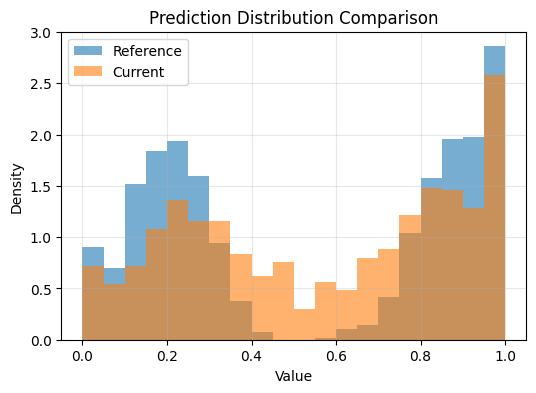

In [5]:
fig1 = plot_distribution(ref_df["pred"], cur_df["pred"])
plt.show()

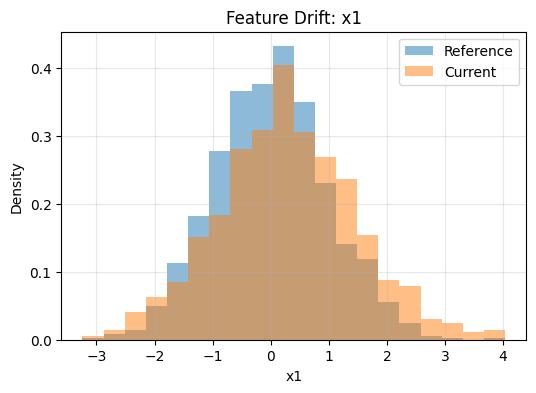

In [6]:
fig2 = plot_feature_histograms(ref_df["x1"], cur_df["x1"], feature_name="x1")
plt.show()

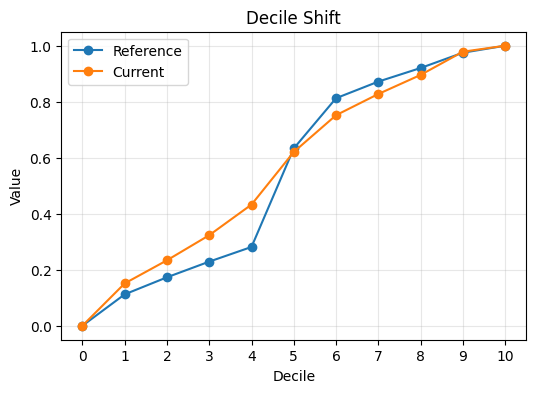

In [7]:
import numpy as np

ref_deciles = np.quantile(ref_df["pred"], np.linspace(0, 1, 11))
cur_deciles = np.quantile(cur_df["pred"], np.linspace(0, 1, 11))

fig3 = plot_deciles(ref_deciles, cur_deciles)
plt.show()

In [8]:
plots = {
    "Prediction Distribution": fig1,
    "Feature Drift: x1": fig2,
    "Prediction Decile Shift": fig3,
}

report = ReportBuilder(
    monitor_output=results,
    plots=plots,
    title="momo-ml Demo Report"
)

html = report.to_html()
html[:1000]  # print beginning

'<html><head><title>momo-ml Demo Report</title>\n            <style>\n                body { font-family: -apple-system, BlinkMacSystemFont, \'Segoe UI\', Roboto, sans-serif; \n                       padding: 20px; line-height: 1.6; }\n                h1 { text-align:center; margin-bottom:30px; }\n                h2 { color:#2d6cdf; }\n            </style>\n        </head><body><h1>momo-ml Demo Report</h1><h2 style=\'margin-top:30px;\'>Performance Drift</h2>\n<pre style=\'background:#f5f5f5;padding:10px;border-radius:4px;\'>{\n  "task_type": "classification",\n  "reference": {\n    "auc": 1.0,\n    "accuracy": 1.0,\n    "precision": 1.0,\n    "recall": 1.0,\n    "f1": 1.0\n  },\n  "current": {\n    "auc": 0.998317230273752,\n    "accuracy": 0.978,\n    "precision": 0.9692028985507246,\n    "recall": 0.9907407407407407,\n    "f1": 0.9798534798534798\n  },\n  "delta": {\n    "auc": -0.0016827697262480346,\n    "accuracy": -0.02200000000000002,\n    "precision": -0.030797101449275388,\n  

In [9]:
report.save_html("momo_report_demo.html")
print("Report saved as momo_report_demo.html")

Report saved as momo_report_demo.html
